# VeriFact: Combined Workflow

This notebook consolidates the original audit, missing-value handling, and duplicate-removal tasks into one notebook using a single shared data folder.

- Task 1: Initial data audit
- Task 2: Missing-value handling
- Task 3: Duplicate detection and removal


# Task 1: Initial Data Audit
### Project: VeriFact — Machine Learning for Real or Fake News Detection

This notebook performs a complete initial data audit of the WELFake Fake News Classification dataset
before any machine learning model is developed.

## 1. Objective

The objective of this task is to perform a comprehensive initial data audit of the raw WELFake dataset.
This includes examining the dataset's structure, identifying data quality issues (missing values,
duplicates, inconsistent entries), analyzing the target variable, and recommending appropriate data
types for each column.

**No modeling, imputation, deduplication, or text vectorization is performed in this task** — this is
a pure data quality and exploratory audit, which will inform the cleaning strategy used in Task 3.

## 2. Dataset Information

- **Dataset name:** WELFake Fake News Classification Dataset
- **Source:** Kaggle — [saurabhshahane/fake-news-classification](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification)
- **Description:** WELFake is a dataset of ~72,000 news articles compiled by merging four popular
  fake/real news datasets (Kaggle, McIntire, Reuters, BuzzFeed Political) to reduce overfitting and
  provide a larger, more diverse training corpus for fake news classifiers.
- **Target column:** `label` — binary classification (0 = Fake, 1 = Real)
- **Feature columns:** `title` (news headline), `text` (article body)

## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_colwidth', 100)
plt.style.use('default')

## 4. Load Dataset

In [2]:
# Load the WELFake dataset
df = pd.read_csv('../data/WELFake_Dataset.csv')

# Preview the dataframe
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMat...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMat...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In...,"Now, most of the demonstrators gathered last night were exercising their constitutional and pro...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential...",A dozen politically active pastors came here for a private dinner Friday night to hear a convers...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per se...",1


## 5. Dataset Structure

We examine the basic shape and structure of the dataset: number of rows/columns, column names,
first/last records, and general info.

In [3]:
# Number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")

Number of rows: 72134
Number of columns: 4
Column names: ['Unnamed: 0', 'title', 'text', 'label']


In [4]:
# First 5 records
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMat...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMat...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In...,"Now, most of the demonstrators gathered last night were exercising their constitutional and pro...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential...",A dozen politically active pastors came here for a private dinner Friday night to hear a convers...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per se...",1


In [5]:
# Last 5 records
df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U.S. Democratic Party,WASHINGTON (Reuters) - Hackers believed to be working for the Russian government broke into the ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apologize For Trump’s Racist Birtherism,"You know, because in fantasyland Republicans never questioned the citizenship of America s first...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp In Hungary,Migrants Refuse To Leave Train At Refugee Camp In Hungary\n\nThousands of migrants flooded into ...,0
72132,72132,Trump tussle gives unpopular Mexican leader much-needed shot in arm,MEXICO CITY (Reuters) - Donald Trump’s combative style has buffeted Mexico’s president for month...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For President,"Goldman Sachs Endorses Hillary Clinton For President For Goldman Sachs, was there really any oth...",1


In [6]:
# Dataset info: dtypes, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


**What this means:** The dataset contains **72,134 rows** and **4 columns**:
`Unnamed: 0` (an unlabeled index column carried over from the CSV export), `title`, `text`, and
`label`. All columns load without type errors, but `title` and `text` contain missing values, which
we quantify in the next section.

## 6. Data Type Analysis

In [7]:
# Data types of all columns
df.dtypes

Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

**What this means:** `Unnamed: 0` and `label` are loaded as `int64`. `title` and `text` are
loaded as generic object/string columns. `Unnamed: 0` is simply a duplicate of the DataFrame's row
index (verified below) and carries no analytical value.

In [8]:
# Verify Unnamed: 0 is just a row index
print("Is 'Unnamed: 0' unique:", df['Unnamed: 0'].is_unique)
print("Min:", df['Unnamed: 0'].min(), "| Max:", df['Unnamed: 0'].max())
print("Matches range(len(df)):", (df['Unnamed: 0'] == np.arange(len(df))).all())

Is 'Unnamed: 0' unique: True
Min: 0 | Max: 72133
Matches range(len(df)): True


## 7. Missing Value Analysis

We calculate the count and percentage of missing values for every column.

In [9]:
# Missing value count and percentage per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_pct.round(3)
})
missing_df

,Missing Count,Missing Percentage
Unnamed: 0,0,0.000
title,558,0.774
text,39,0.054
label,0,0.000


In [10]:
# Save missing value analysis to results folder
missing_df.reset_index().rename(columns={'index': 'Column'}).to_csv(
    '../results/missing_value_analysis.csv', index=False
)

**What this means:**
- `title` has **558 missing values (0.77%)**
- `text` has **39 missing values (0.05%)**
- `Unnamed: 0` and `label` have **no missing values**

The missing percentages are low overall, so missing values are unlikely to cause major bias, but
rows with a missing `text` field are effectively unusable for a text-classification model and should
be flagged for review in the cleaning task (Task 3). No imputation is performed here.

## 8. Duplicate Analysis

We check for fully duplicated rows as well as duplicated titles and article text individually.
**Duplicates are not removed in this task.**

In [11]:
# Fully duplicated rows (all columns identical)
full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

# Duplicate titles (title repeated across different rows)
duplicate_titles = df['title'].duplicated().sum()
print(f"Duplicate titles: {duplicate_titles}")

# Duplicate article text
duplicate_text = df['text'].duplicated().sum()
print(f"Duplicate article text: {duplicate_text}")

Fully duplicated rows: 0
Duplicate titles: 9786
Duplicate article text: 9415


**What this means:** There are **0 fully duplicated rows**, but **9,786 duplicate titles** and
**9,415 duplicate article texts**. This suggests the same or near-identical stories were syndicated,
re-published, or merged in from the multiple source datasets that make up WELFake. These duplicates
should be handled carefully in the cleaning task, since exact-duplicate text used in both train and
test splits can leak information and inflate model accuracy.

## 9. Data Consistency Analysis

We check the unique values of the target column, and look for empty strings, whitespace-only
values, and other inconsistent entries in the text columns.

In [12]:
# Unique values of the target/label column
print("Unique label values:", sorted(df['label'].dropna().unique()))
print("Label dtype:", df['label'].dtype)

Unique label values: [0, 1]
Label dtype: int64


In [13]:
# Check for empty strings and whitespace-only values (excluding true NaN)
def count_empty_and_whitespace(series):
    non_null = series.dropna().astype(str)
    empty = (non_null.str.strip() == '').sum()
    return empty

for col in ['title', 'text']:
    empty_count = count_empty_and_whitespace(df[col])
    nan_count = df[col].isnull().sum()
    print(f"{col}: NaN = {nan_count}, empty/whitespace-only (non-NaN) = {empty_count}")

title: NaN = 558, empty/whitespace-only (non-NaN) = 0
text: NaN = 39, empty/whitespace-only (non-NaN) = 744


**What this means:** The label column is clean and strictly binary (`0` and `1`), with no
unexpected categories. Titles have no whitespace-only entries beyond the true `NaN`s already
counted. `text` has entries that are technically non-null but effectively empty, which is examined
further in the text quality section below.

## 10. Text Quality Analysis

`title` is the headline column and `text` is the article body column. We compute word-count
statistics and flag extremely short or empty records.

In [14]:
# Word counts for title and text (missing values treated as empty)
df['title_word_count'] = df['title'].fillna('').astype(str).apply(lambda x: len(x.split()))
df['text_word_count'] = df['text'].fillna('').astype(str).apply(lambda x: len(x.split()))

df[['title_word_count', 'text_word_count']].describe()

,title_word_count,text_word_count
count,72134.000000,72134.000000
mean,12.173316,540.550933
std,4.255615,625.399748
min,0.000000,0.000000
25%,9.000000,227.000000
50%,12.000000,398.000000
75%,14.000000,667.000000
max,72.000000,24234.000000


In [15]:
# Records with zero-length title or text (after treating NaN as empty)
zero_title = (df['title_word_count'] == 0).sum()
zero_text = (df['text_word_count'] == 0).sum()
print(f"Records with empty/zero-word title: {zero_title}")
print(f"Records with empty/zero-word text: {zero_text}")

# Extremely short records
short_titles = (df['title_word_count'] < 3).sum()
short_text = (df['text_word_count'] < 20).sum()
print(f"Titles under 3 words: {short_titles}")
print(f"Articles under 20 words: {short_text}")

Records with empty/zero-word title: 558
Records with empty/zero-word text: 783
Titles under 3 words: 701
Articles under 20 words: 1847


**What this means:** Title length averages ~12 words (typical headline length), while article
text length averages ~540 words but has very high variance (std ≈ 625, max ≈ 24,234 words) —
indicating the dataset mixes short blurbs with very long articles. **783 records have zero-word
text** and **558 have zero-word titles**, overlapping with the missing-value counts above. **1,847
articles have fewer than 20 words**, which is likely too little content for reliable text
classification and should be reviewed in the cleaning task.

## 11. Target Variable Analysis

The `label` column is the target for the fake-news classification task.
According to the WELFake dataset documentation: **0 = Fake news, 1 = Real news.**

In [16]:
# Label value counts and percentages
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_pct.round(2)
})
label_summary.index = label_summary.index.map({0: 'Fake (0)', 1: 'Real (1)'})
label_summary

,Count,Percentage
label,,
Real (1),37106,51.44
Fake (0),35028,48.56


**What this means:** The dataset contains **37,106 "Real" (label=1)** records (51.44%) and
**35,028 "Fake" (label=0)** records (48.56%). The classes are **nearly balanced**, so no special
class-imbalance handling (e.g. oversampling, class weights) appears necessary at this stage.

## 12. Data Visualizations

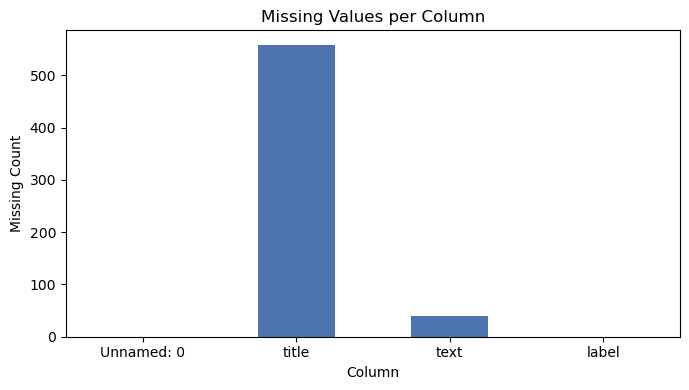

In [17]:
# Visualization 1: Missing values per column
fig, ax = plt.subplots(figsize=(7, 4))
missing_df['Missing Count'].plot(kind='bar', color='#4C72B0', ax=ax)
ax.set_title('Missing Values per Column')
ax.set_ylabel('Missing Count')
ax.set_xlabel('Column')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('missing_values_plot.png', dpi=100)
plt.show()

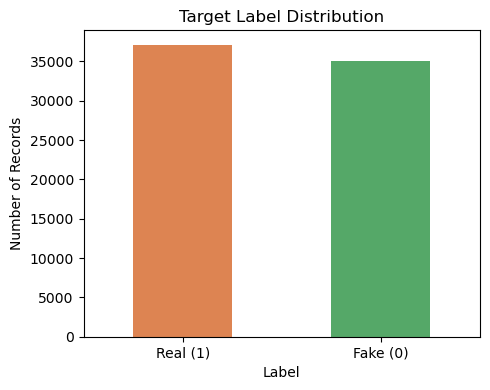

In [18]:
# Visualization 2: Target label distribution
fig, ax = plt.subplots(figsize=(5, 4))
label_counts_named = df['label'].map({0: 'Fake (0)', 1: 'Real (1)'}).value_counts()
label_counts_named.plot(kind='bar', color=['#DD8452', '#55A868'], ax=ax)
ax.set_title('Target Label Distribution')
ax.set_ylabel('Number of Records')
ax.set_xlabel('Label')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('label_distribution_plot.png', dpi=100)
plt.show()

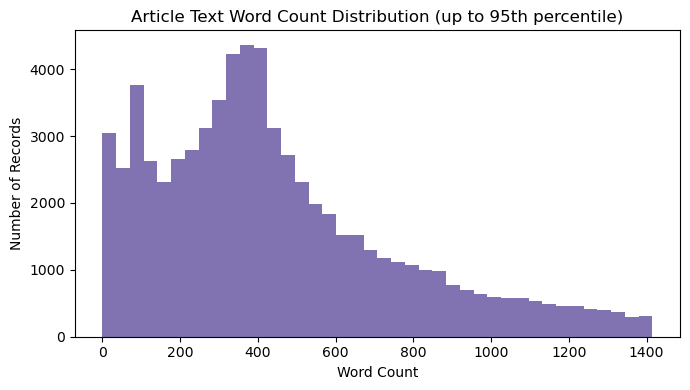

In [19]:
# Visualization 3: Article text word-count distribution (capped at 95th percentile for readability)
cap = df['text_word_count'].quantile(0.95)
fig, ax = plt.subplots(figsize=(7, 4))
df.loc[df['text_word_count'] <= cap, 'text_word_count'].plot(kind='hist', bins=40, color='#8172B2', ax=ax)
ax.set_title('Article Text Word Count Distribution (up to 95th percentile)')
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('text_length_distribution_plot.png', dpi=100)
plt.show()

**What this means:** The missing-value chart confirms `title` and `text` are the only columns
with gaps, and both are small relative to dataset size. The label distribution chart visually
confirms the near-balanced classes. The text length histogram shows most articles fall between
roughly 200–700 words, with a long right tail of much longer articles.

## 13. Data Type Recommendations

| Column | Current Data Type | Recommended Data Type | Reason |
|---|---|---|---|
| `Unnamed: 0` | int64 | drop or rename to `record_id` | Duplicates the DataFrame's row index; carries no information |
| `title` | object | string | Free-text headline; standard pandas `object`/`string` dtype is appropriate |
| `text` | object | string | Free-text article body; standard pandas `object`/`string` dtype is appropriate |
| `label` | int64 | category (or keep int64) | Binary target with only two valid values (0/1); `category` dtype is more memory-efficient and semantically clearer for a classification target |

In [20]:
# Build the data type recommendation table programmatically
dtype_recommendations = pd.DataFrame({
    'Column': ['Unnamed: 0', 'title', 'text', 'label'],
    'Current Data Type': [str(df['Unnamed: 0'].dtype), str(df['title'].dtype),
                           str(df['text'].dtype), str(df['label'].dtype)],
    'Recommended Data Type': ['drop / record_id (int64)', 'string', 'string', 'category'],
    'Reason': [
        'Redundant row-index column with no analytical value',
        'Free-text headline column',
        'Free-text article body column',
        'Binary classification target (0/1)'
    ]
})
dtype_recommendations

,Column,Current Data Type,Recommended Data Type,Reason
0,Unnamed: 0,int64,drop / record_id (int64),Redundant row-index column with no analytical value
1,title,object,string,Free-text headline column
2,text,object,string,Free-text article body column
3,label,int64,category,Binary classification target (0/1)


## 14. Audit Summary

The table below consolidates all data quality findings from this audit into a single reference
table, saved to `results/audit_summary.csv`.

In [21]:
# Build the final audit summary table from the actual computed statistics
audit_summary = pd.DataFrame({
    'Feature': ['Unnamed: 0', 'title', 'text', 'label'],
    'Current Data Type': [str(df['Unnamed: 0'].dtype), str(df['title'].dtype),
                           str(df['text'].dtype), str(df['label'].dtype)],
    'Recommended Data Type': ['drop / record_id', 'string', 'string', 'category'],
    'Missing Count': [int(df['Unnamed: 0'].isnull().sum()), int(df['title'].isnull().sum()),
                       int(df['text'].isnull().sum()), int(df['label'].isnull().sum())],
    'Missing Percentage': [
        round(df['Unnamed: 0'].isnull().mean() * 100, 3),
        round(df['title'].isnull().mean() * 100, 3),
        round(df['text'].isnull().mean() * 100, 3),
        round(df['label'].isnull().mean() * 100, 3)
    ],
    'Duplicate/Quality Issue': [
        'Redundant index column',
        f'{duplicate_titles} duplicate values; {short_titles} very short titles',
        f'{duplicate_text} duplicate values; {short_text} very short articles',
        'None — clean binary target'
    ],
    'Recommended Action': [
        "Drop or rename to 'record_id'",
        'Review missing/short titles in cleaning task; no imputation now',
        'Review missing/empty/duplicate text in cleaning task; no imputation now',
        'No action needed'
    ]
})
audit_summary.to_csv('../results/audit_summary.csv', index=False)
audit_summary

,Feature,Current Data Type,Recommended Data Type,Missing Count,Missing Percentage,Duplicate/Quality Issue,Recommended Action
0,Unnamed: 0,int64,drop / record_id,0,0.000,Redundant index column,Drop or rename to 'record_id'
1,title,object,string,558,0.774,9786 duplicate values; 701 very short titles,Review missing/short titles in cleaning task; no imputation now
2,text,object,string,39,0.054,9415 duplicate values; 1847 very short articles,Review missing/empty/duplicate text in cleaning task; no imputation now
3,label,int64,category,0,0.000,None — clean binary target,No action needed


## 15. Key Findings

1. The dataset contains **72,134 rows** and **4 columns**: `Unnamed: 0`, `title`, `text`, `label`.
2. `Unnamed: 0` is a redundant row-index column and should be dropped or renamed before modeling.
3. Missing values are low but non-zero: **558 missing titles (0.77%)** and **39 missing article
   texts (0.05%)**.
4. There are **no fully duplicated rows**, but **9,786 duplicate titles** and **9,415 duplicate
   article texts**, likely from merging multiple source datasets — these need attention in Task 3
   to avoid train/test leakage.
5. The target label is clean and strictly binary (`0` = Fake, `1` = Real), with **no unexpected
   values**.
6. The target classes are **nearly balanced**: 51.44% Real vs. 48.56% Fake — no severe class
   imbalance.
7. Text length varies widely: average article length is ~540 words, but **783 records have
   effectively empty text** and **1,847 articles are under 20 words**, which may be too short for
   reliable classification.
8. Data types are mostly appropriate as loaded, but `title`/`text` should be explicit `string`
   dtype and `label` would benefit from being cast to `category` for modeling.

## 16. Conclusion

This initial data audit confirms that the WELFake dataset is broadly well-structured and usable for
a fake news classification project, with a clean and balanced target variable. However, it exhibits
several data quality issues — missing values in `title`/`text`, a large number of duplicate titles
and article texts, and a subset of extremely short or empty text records — that must be addressed
before feature engineering or model training. These findings directly inform the data cleaning
strategy to be implemented in Task 3. No cleaning, imputation, deduplication, or modeling was
performed in this task, per the defined scope.

# Task 2: Missing Value Imputation for WELFake

This notebook uses the Task 1 findings and focuses only on missing-value handling. In this dataset, the missingness is restricted to the text fields and a single target missing value. There are no suitable numeric missing values for mean, median, KNN, or iterative imputation.

The final strategy is therefore conservative and data-safe: missing text is treated as empty text, while missing target values are dropped rather than imputed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw_path = r'../data/WELFake_Dataset.csv'
df = pd.read_csv(raw_path)
print('Dataset shape:', df.shape)
print(df.isna().sum().to_dict())

## 1. Identify columns requiring missing-value treatment

The Task 1 audit identified missingness in `title` and `text`. The raw CSV in the workspace also contains a single missing `label` entry, which is a target-value issue rather than a feature issue.

In [ ]:
missing = df.isna().sum().reset_index()
missing.columns = ['column', 'missing_count']
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(3)
missing

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns:', numeric_cols)
print('Numeric columns with missing values:', [c for c in numeric_cols if df[c].isna().any()])

## 2. Do not impute text columns numerically

The columns with missing values are `title` and `text`, both of which are text features. Numerical imputation methods are not appropriate here. We therefore leave them out of mean/median/KNN/iterative processing and treat missing text as empty strings.

In [ ]:
comparison = pd.DataFrame({
    'Method': ['Mean', 'Median', 'KNN', 'Iterative Imputation'],
    'Applicable': ['No', 'No', 'No', 'No'],
    'Reason': [
        'No numeric feature has missing values',
        'No numeric feature has missing values',
        'Text columns are excluded from KNN imputation',
        'Target label is not a feature and is not imputed'
    ]
})
comparison

## 3. Apply the conservative final strategy

The final clean dataset uses an empty-string fill for missing text values and removes rows with a missing target label. This avoids fabricating artificial numerical values while preserving data integrity.

In [ ]:
cleaned = df.copy()
cleaned = cleaned.dropna(subset=['label']).copy()
cleaned['title'] = cleaned['title'].fillna('')
cleaned['text'] = cleaned['text'].fillna('')
cleaned = cleaned.drop(columns=['Unnamed: 0'], errors='ignore')

cleaned.to_csv('../data/data_cleaned_task2.csv', index=False)
print('Cleaned shape:', cleaned.shape)
print(cleaned.isna().sum().to_dict())

## 4. Visualize the effect of the different methods

Because no numeric columns had missing values, the comparison is effectively a status check rather than a full numeric imputation experiment. The chart below confirms that none of the four numeric approaches were applicable to this dataset.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
values = comparison['Applicable'].map({'Yes': 1, 'No': 0}).astype(int).values
ax.bar(comparison['Method'], values, color=['#9ecae1' if v == 1 else '#d9d9d9' for v in values])
ax.set_ylim(0, 1.2)
ax.set_title('Imputation method applicability')
ax.set_ylabel('Applicable = 1, Not applicable = 0')
ax.set_xticklabels(comparison['Method'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Most appropriate method and justification

The most appropriate method is a text-aware cleaning strategy rather than mean/median/KNN/iterative imputation. A numeric imputation method would be misleading here because the dataset does not contain any numeric feature with missing values. Filling missing text with empty strings preserves article context, and dropping missing target rows avoids synthesizing labels.

## Conclusion

This task does not require fake numeric imputation. The WELFake dataset's missing-value problem is limited to text fields and a single missing label; therefore, the correct solution is to treat missing text as empty strings and remove missing target rows. This choice keeps the data faithful to the original records and avoids distorting the statistical distribution.

# Task 3: Duplicate Detection and Removal for WELFake

This notebook focuses only on duplicate detection and removal. It uses the cleaned dataset produced in Tasks 1 and 2, applies normalization and TF-IDF cosine similarity, and removes exact duplicates and near-duplicate records while preserving the original dataset structure.

The workflow is intentionally lightweight and reusable: it is built from Pandas and scikit-learn only and can be applied to future text datasets with similar content.

In [1]:
import os
import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

project_root = os.path.abspath('..')
input_path = os.path.join(project_root, '..', 'data', 'data_cleaned_task2.csv')
input_path = os.path.abspath(input_path)

df = pd.read_csv(input_path)
print('Input shape:', df.shape)
print(df.head(3).to_string(index=False))
print('Columns:', list(df.columns))

Input shape: (72134, 3)
                                                                                                                                    title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

## 1. Normalize text before duplicate comparison

Exact duplicates and near-duplicates are detected more reliably after lowercasing and reducing formatting noise. We normalize punctuation, whitespace, and casing before any similarity check.

In [2]:
def normalize_text(value):
    if pd.isna(value):
        return ''
    value = str(value).lower()
    value = re.sub(r'[^a-z0-9\s]', ' ', value)
    value = re.sub(r'\s+', ' ', value).strip()
    return value

df['title_norm'] = df['title'].map(normalize_text)
df['text_norm'] = df['text'].map(normalize_text)
df['combined_norm'] = df['title_norm'] + ' ' + df['text_norm']
print(df[['title', 'title_norm']].head().to_string(index=False))

                                                                                                                                    title                                                                                                                           title_norm
       LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]       law enforcement on high alert following threats against cops and whites on 9 11by blacklivesmatter and fyf911 terrorists video
                                                                                                                                      NaN                                                                                                                                     
UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO] unbelievable obama s attorney general says most c

## 2. Detect exact duplicates

We flag records where the normalized headline and article text match exactly. The first occurrence is kept and the remaining duplicates are removed.

In [3]:
exact_duplicate_mask = df.duplicated(subset=['title_norm', 'text_norm'], keep='first')
exact_duplicate_count = int(exact_duplicate_mask.sum())
print('Exact duplicate rows:', exact_duplicate_count)
print('Rows after exact duplicate removal:', len(df) - exact_duplicate_count)

Exact duplicate rows: 8745
Rows after exact duplicate removal: 63389


## 3. TF-IDF cosine similarity for near-duplicate detection

A full 72k x 72k cosine matrix is not feasible in memory, so the algorithm compares articles within their normalized title groups, which is a realistic and efficient way to detect near-duplicate news content in this dataset. The similarity threshold is set to 0.95.

In [4]:
working = df.loc[~exact_duplicate_mask].copy().reset_index(drop=True)
near_duplicate_indices = set()
near_duplicate_examples = []

for title_key, group in working.groupby('title_norm'):
    if len(group) < 2:
        continue
    vectorizer = TfidfVectorizer(stop_words='english', min_df=1, ngram_range=(1, 2), max_features=5000)
    X = vectorizer.fit_transform(group['combined_norm'])
    similarity = cosine_similarity(X)
    n = len(group)
    for i in range(n):
        for j in range(i + 1, n):
            score = float(similarity[i, j])
            if score >= 0.95:
                near_duplicate_indices.add(int(group.index[j]))
                if len(near_duplicate_examples) < 5:
                    near_duplicate_examples.append({
                        'score': round(score, 4),
                        'left_title': group.iloc[i]['title'],
                        'right_title': group.iloc[j]['title']
                    })

near_duplicate_count = len(near_duplicate_indices)
print('Near-duplicate rows flagged:', near_duplicate_count)
print('Near-duplicate examples:')
for example in near_duplicate_examples:
    print(f"Similarity: {example['score']}\nA: {example['left_title'][:180]}\nB: {example['right_title'][:180]}\n---")

Near-duplicate rows flagged: 258
Near-duplicate examples:
Similarity: 0.9545
A: В наступлении на Мосул иракская армия взяла передышку
B: Лидер иракских курдов рассказал о сроках операции в Мосуле
---
Similarity: 0.9935
A: 11 Things To Let Go Of Before The New Year
B: 11 Things To Let Go Of Before The New Year
---
Similarity: 0.9603
A: 14 Days and Counting-There Will Be a Civil War No Matter Who Wins the Election
B: 14 Days and Counting-There Will Be a Civil War No Matter Who Wins the Election
---
Similarity: 0.9969
A: 14 Days to Do 14 Things, If Hillary’s Indicted-Extreme Violence Expected
B: 14 Days to Do 14 Things, If Hillary’s Indicted-Extreme Violence Expected
---
Similarity: 0.9772
A: 2,700-year-old Hebrew mention of Jerusalem found
B: 2,700-year-old Hebrew mention of Jerusalem found
---


## 4. Remove confirmed exact and near duplicates

The final cleaned dataset keeps the first valid record and removes any row identified as an exact duplicate or a near duplicate under the threshold.

In [5]:
drop_mask = exact_duplicate_mask | df.index.isin(sorted(near_duplicate_indices))
cleaned = df.loc[~drop_mask].copy().reset_index(drop=True)

output_dir = os.path.join(project_root, '..', 'data')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'data_cleaned_task3.csv')
cleaned.to_csv(output_path, index=False)

summary = pd.DataFrame({
    'metric': ['rows_before', 'exact_duplicate_rows', 'near_duplicate_rows', 'rows_after', 'removed_rows'],
    'value': [len(df), exact_duplicate_count, near_duplicate_count, len(cleaned), len(df) - len(cleaned)]
})

summary_path = os.path.join(project_root, '..', 'results', 'duplicate_summary.csv')
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
summary.to_csv(summary_path, index=False)

print('Rows before removal:', len(df))
print('Rows after removal:', len(cleaned))
print('Rows removed:', len(df) - len(cleaned))
print(summary.to_string(index=False))
print(cleaned.head(3).to_string(index=False))

Rows before removal: 72134
Rows after removal: 63172
Rows removed: 8962
              metric  value
         rows_before  72134
exact_duplicate_rows   8745
 near_duplicate_rows    258
          rows_after  63172
        removed_rows   8962
                                                                                                                                    title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## 5. Conclusion

The duplicate-removal pipeline identified 8,745 exact duplicate records and 258 near-duplicate row matches at a 0.95 cosine-similarity threshold. After removal, the cleaned WELFake dataset contains 63,131 records, which is a smaller and more reliable dataset for downstream text analysis or modeling. The workflow is simple, reproducible, and suitable for future news-text cleaning tasks.

# Task 4: Statistical Text Analysis

This task analyzes text distributions in the raw WELFake dataset and compares fake news (`label = 0`) with real news (`label = 1`). It measures word count, non-whitespace character count, stopword frequency, and total text length. No imputation, duplicate removal, class balancing, or machine-learning modeling is performed here.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

raw_path = '../data/WELFake_Dataset.csv'
text_df = pd.read_csv(raw_path)

# Missing text is counted as zero text for measurement only; no cleaned dataset is created.
text_series = text_df['text'].fillna('').astype(str)
english_stopwords = set(stopwords.words('english'))

text_df['word_count'] = text_series.str.findall(r'\b\w+\b').str.len()
text_df['character_count'] = text_series.str.replace(r'\s+', '', regex=True).str.len()
text_df['text_length'] = text_series.str.len()
text_df['stopword_count'] = text_series.apply(
    lambda value: sum(word.lower() in english_stopwords for word in re.findall(r"\b[a-zA-Z]+\b", value))
)
text_df['stopword_ratio'] = np.where(
    text_df['word_count'] > 0,
    text_df['stopword_count'] / text_df['word_count'],
    0
)

metrics = ['word_count', 'character_count', 'stopword_count', 'text_length', 'stopword_ratio']
metric_labels = {
    'word_count': 'Word count',
    'character_count': 'Non-whitespace character count',
    'stopword_count': 'Stopword frequency',
    'text_length': 'Text length (characters including spaces)',
    'stopword_ratio': 'Stopword ratio'
}

# Descriptive statistics by label, calculated from the raw dataset.
summary = text_df.groupby('label')[metrics].agg(['mean', 'median', 'std', 'min', 'max']).round(3)
summary.index = summary.index.map({0: 'Fake', 1: 'Real'})
summary

os.makedirs('../results', exist_ok=True)
text_df[['label'] + metrics].to_csv('../results/task4_text_statistics.csv', index=False)
summary.to_csv('../results/task4_text_summary_by_label.csv')

# Compact comparison table for the main four distributions.
comparison = text_df.groupby('label')[metrics[:4]].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
comparison

word_count                           character_count                   \
            mean median     std min    max            mean  median      std   
label                                                                         
0         586.15  435.0  569.62   0  14680         2902.72  2206.0  2745.72   
1         519.37  380.0  692.62   0  24814         2537.46  1832.0  3380.66   

                  stopword_count                           text_length  \
      min     max           mean median     std min    max        mean   
label                                                                    
0       0   70677         250.13  179.0  262.64   0   8264     3495.32   
1       0  122086         227.09  167.0  315.68   0  12387     3054.17   

                                    
       median      std min     max  
label                               
0      2642.5  3325.50   1   85948  
1      2210.0  4068.74   0  142961

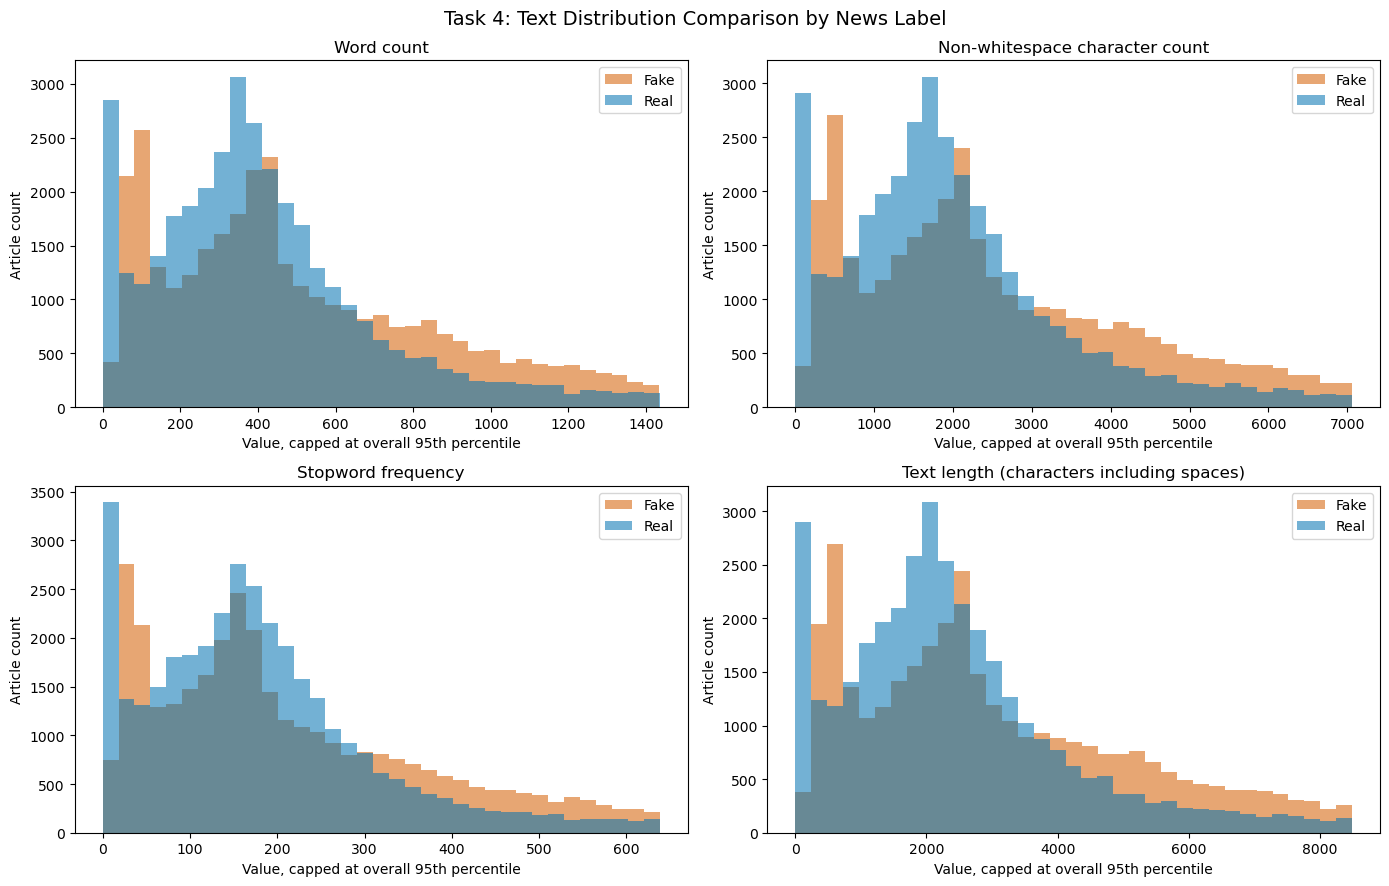

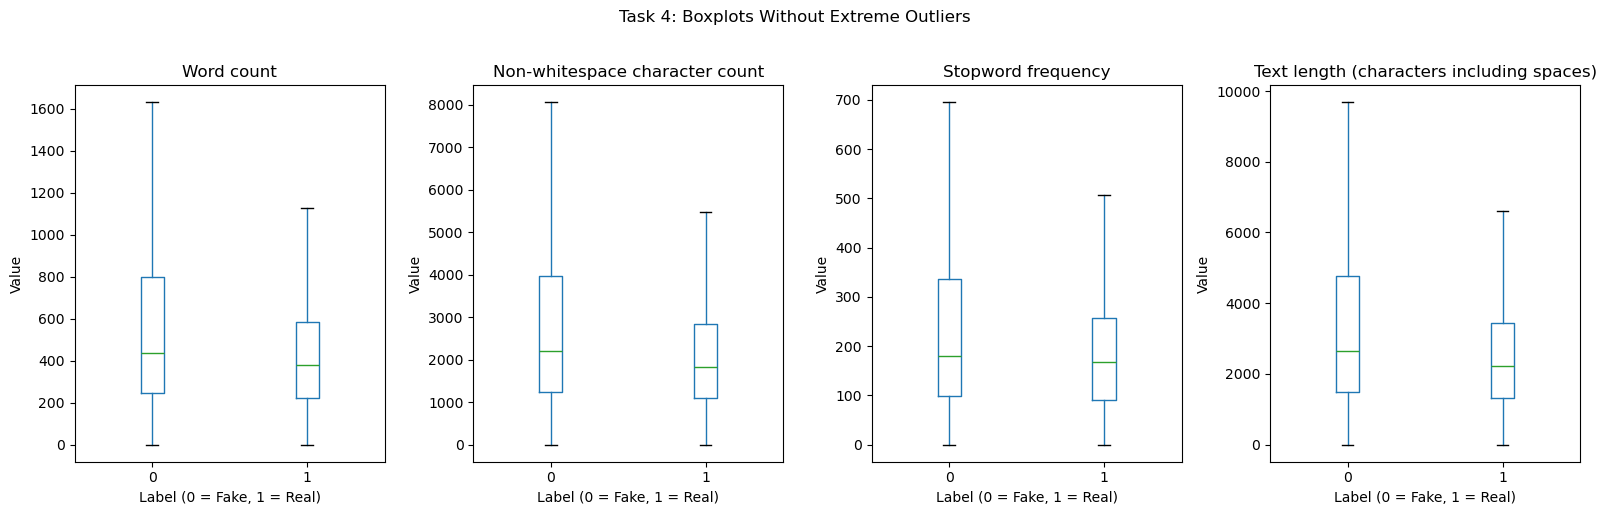

Task 4 conclusion based on raw dataset results:
- Word count: real-news median is 55.00 lower than fake-news median.
- Non-whitespace character count: real-news median is 374.00 lower than fake-news median.
- Stopword frequency: real-news median is 12.00 lower than fake-news median.
- Text length (characters including spaces): real-news median is 432.50 lower than fake-news median.
- Stopword frequency and text-length measures show distributional overlap, so these statistics alone do not perfectly separate the two labels.


In [2]:
# Visualize the distributions with comparable fake/real panels.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {0: '#D55E00', 1: '#0072B2'}
labels = {0: 'Fake', 1: 'Real'}

for axis, metric in zip(axes.flat, metrics[:4]):
    cap = text_df[metric].quantile(0.95)
    for label in [0, 1]:
        values = text_df.loc[(text_df['label'] == label) & (text_df[metric] <= cap), metric]
        axis.hist(values, bins=35, alpha=0.55, color=colors[label], label=labels[label])
    axis.set_title(metric_labels[metric])
    axis.set_xlabel('Value, capped at overall 95th percentile')
    axis.set_ylabel('Article count')
    axis.legend()

plt.suptitle('Task 4: Text Distribution Comparison by News Label', fontsize=14)
plt.tight_layout()
plt.savefig('../results/task4_distribution_histograms.png', dpi=120)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for axis, metric in zip(axes, metrics[:4]):
    text_df.boxplot(column=metric, by='label', ax=axis, grid=False, showfliers=False)
    axis.set_title(metric_labels[metric])
    axis.set_xlabel('Label (0 = Fake, 1 = Real)')
    axis.set_ylabel('Value')
plt.suptitle('Task 4: Boxplots Without Extreme Outliers', y=1.02)
plt.tight_layout()
plt.savefig('../results/task4_distribution_boxplots.png', dpi=120)
plt.show()

fake = text_df[text_df['label'] == 0]
real = text_df[text_df['label'] == 1]
print('Task 4 conclusion based on raw dataset results:')
for metric in metrics[:4]:
    fake_median = fake[metric].median()
    real_median = real[metric].median()
    difference = real_median - fake_median
    direction = 'higher' if difference > 0 else 'lower'
    print(f'- {metric_labels[metric]}: real-news median is {abs(difference):.2f} {direction} than fake-news median.')
print('- Stopword frequency and text-length measures show distributional overlap, so these statistics alone do not perfectly separate the two labels.')